In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
data = pd.read_csv('House Prices.csv')

In [3]:
print(data.head())

   ID             Date     Price  Bedrooms  Bathrooms  Sqft_living  Sqft_lot  \
0   1  20140916T000000  280000.0         6       3.00         2400      9373   
1   2  20150422T000000  300000.0         6       3.00         2400      9373   
2   3  20140508T000000  647500.0         4       1.75         2060     26036   
3   4  20140811T000000  400000.0         3       1.00         1460     43000   
4   5  20150401T000000  235000.0         3       1.00         1430      7599   

   Floors  Waterfront  View  ...  Grade  Sqft_above  Sqft_basement  Yr_built  \
0     2.0           0     0  ...      7        2400              0      1991   
1     2.0           0     0  ...      7        2400              0      1991   
2     1.0           0     0  ...      8        1160            900      1947   
3     1.0           0     0  ...      7        1460              0      1952   
4     1.5           0     0  ...      6        1010            420      1930   

   Yr_renovated  zipcode      Lat     

In [4]:
print(data.describe())

                ID         Price      Bedrooms     Bathrooms   Sqft_living  \
count  21613.00000  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   10807.00000  5.401822e+05      3.370842      2.114757   2079.899736   
std     6239.28002  3.673622e+05      0.930062      0.770163    918.440897   
min        1.00000  7.500000e+04      0.000000      0.000000    290.000000   
25%     5404.00000  3.219500e+05      3.000000      1.750000   1427.000000   
50%    10807.00000  4.500000e+05      3.000000      2.250000   1910.000000   
75%    16210.00000  6.450000e+05      4.000000      2.500000   2550.000000   
max    21613.00000  7.700000e+06     33.000000      8.000000  13540.000000   

           Sqft_lot        Floors    Waterfront          View     Condition  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   1.510697e+04      1.494309      0.007542      0.234303      3.409430   
std    4.142051e+04      0.539989      0.086517      0.76631

In [5]:
data = data.fillna(data.median())  # Fill numeric missing values with median

In [6]:
for col in data.select_dtypes(include='object').columns:
    data[col] = LabelEncoder().fit_transform(data[col])

In [7]:
scaler = StandardScaler()
features = data.drop('Price', axis=1)
features_scaled = scaler.fit_transform(features)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(features_scaled, data['Price'], test_size=0.2, random_state=42)

In [9]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost Regressor
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


In [10]:
# Step 9: Evaluate Models
def evaluate_model(y_true, y_pred):
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R² Score:", r2_score(y_true, y_pred))

print("Linear Regression Evaluation:")
evaluate_model(y_test, y_pred_lr)
print("\nRandom Forest Evaluation:")
evaluate_model(y_test, y_pred_rf)
print("\nXGBoost Evaluation:")
evaluate_model(y_test, y_pred_xgb)

Linear Regression Evaluation:
RMSE: 190227.31279591587
MAE: 124100.53635043385
R² Score: 0.6975665477190021

Random Forest Evaluation:
RMSE: 121098.0059768667
MAE: 68112.24906083738
R² Score: 0.8774373718664177

XGBoost Evaluation:
RMSE: 121473.81179178794
MAE: 66525.47456012896
R² Score: 0.8766754895045686


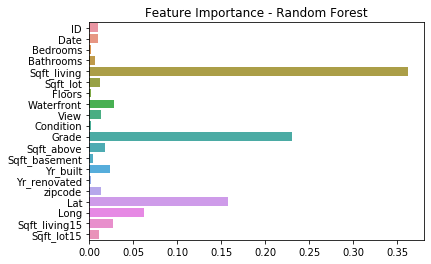

In [11]:
# Step 10: Feature Importance (Random Forest)
importances = rf_model.feature_importances_
feature_names = data.drop('Price', axis=1).columns
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance - Random Forest')
plt.show() 